In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from kagglehub import KaggleDatasetAdapter

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mussabomair/mobile-phone-prices/result.csv
/kaggle/input/datasets/mussabomair/mobile-phone-prices/train.csv
/kaggle/input/datasets/mussabomair/mobile-phone-prices/test.csv


Dataset link :- https://www.kaggle.com/datasets/mussabomair/mobile-phone-prices/data

In [2]:
train_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"mussabomair/mobile-phone-prices","train.csv")
test_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"mussabomair/mobile-phone-prices","test.csv")
# Handle any stray leading/trailing spaces in headers
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

## 1. Understanding Data

In [3]:
train_df.head()

,camera,age,ram,cpu_score,slot_sd,sims,price
0,110,2,4,89,1,2,31596
1,187,0,4,42,0,1,33530
2,100,2,4,52,0,2,9262
3,22,2,6,82,0,2,62199
4,114,2,12,88,1,1,66287


In [4]:
train_df.shape

(1000, 7)

In [5]:
train_df.columns

Index(['camera', 'age', 'ram', 'cpu_score', 'slot_sd', 'sims', 'price'], dtype='object')

In [6]:
train_df.duplicated().sum()

np.int64(0)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   camera     1000 non-null   int64
 1   age        1000 non-null   int64
 2   ram        1000 non-null   int64
 3   cpu_score  1000 non-null   int64
 4   slot_sd    1000 non-null   int64
 5   sims       1000 non-null   int64
 6   price      1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


In [8]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
camera,1000.0,105.934,56.086909,8.0,58.0,108.0,153.25,200.0
age,1000.0,1.439,1.106120,0.0,0.0,1.0,2.00,3.0
ram,1000.0,9.360,4.337882,4.0,6.0,8.0,12.00,16.0
cpu_score,1000.0,70.804,17.546723,40.0,57.0,72.0,86.00,100.0
slot_sd,1000.0,0.484,0.499994,0.0,0.0,0.0,1.00,1.0
sims,1000.0,1.495,0.500225,1.0,1.0,1.0,2.00,2.0
price,1000.0,39198.370,17778.387677,8016.0,23958.0,39056.0,54830.00,69922.0


#### As the data is already cleaned so we directly jump into EDA

## 2. EDA

### 2.1 Univariate Analysis

<Axes: xlabel='camera', ylabel='Count'>

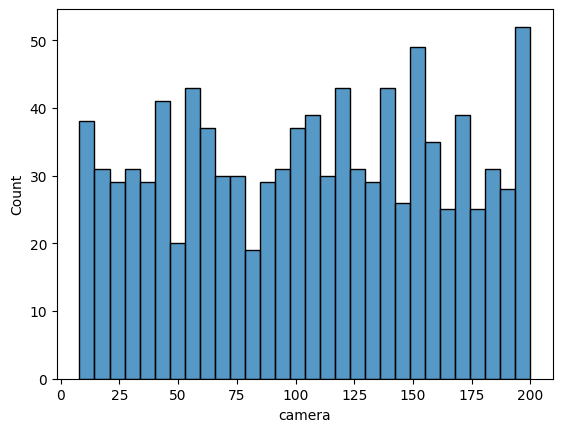

In [9]:
sns.histplot(train_df['camera'],bins=30)

<Axes: xlabel='age', ylabel='Count'>

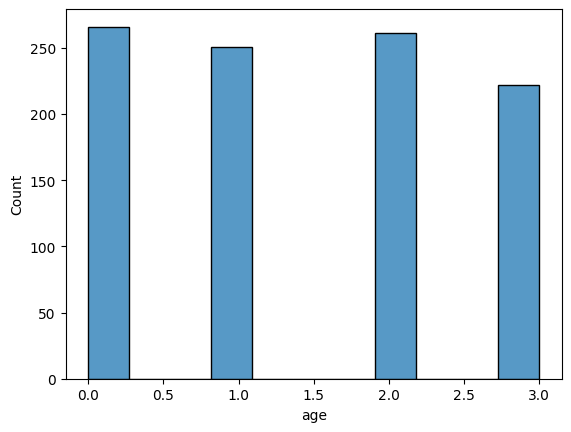

In [10]:
sns.histplot(train_df['age'])

<Axes: xlabel='ram', ylabel='Count'>

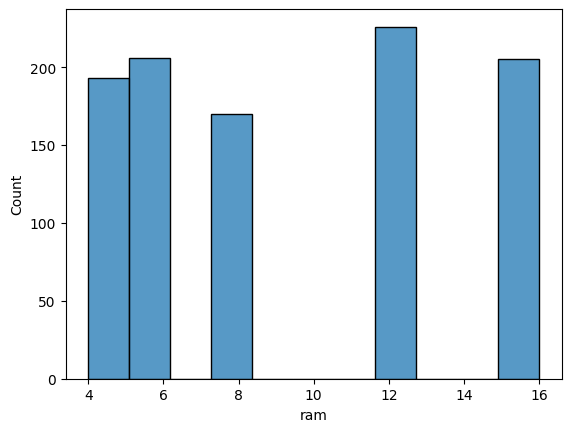

In [11]:
sns.histplot(train_df['ram'])

<Axes: xlabel='cpu_score', ylabel='Count'>

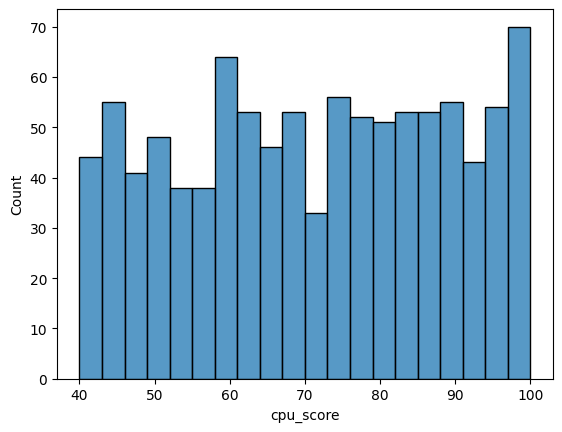

In [12]:
sns.histplot(train_df['cpu_score'],bins=20)

<Axes: xlabel='slot_sd', ylabel='count'>

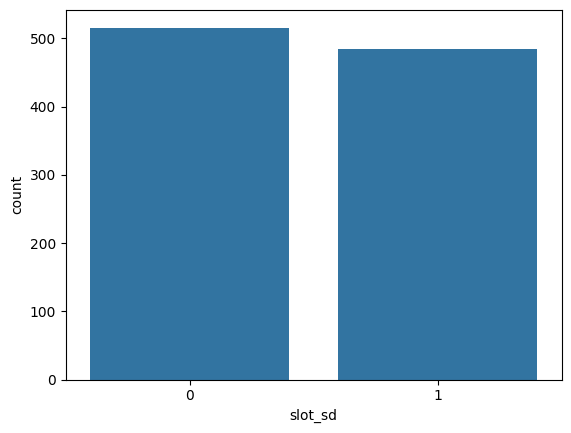

In [13]:
sns.countplot(x = train_df['slot_sd'])

<Axes: xlabel='sims', ylabel='count'>

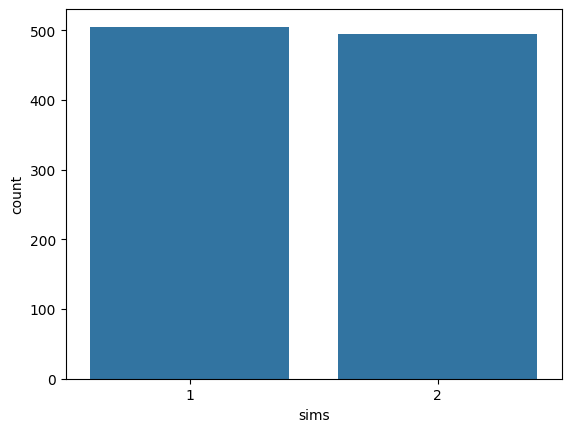

In [14]:
sns.countplot(x=train_df['sims'])

<Axes: xlabel='price', ylabel='Count'>

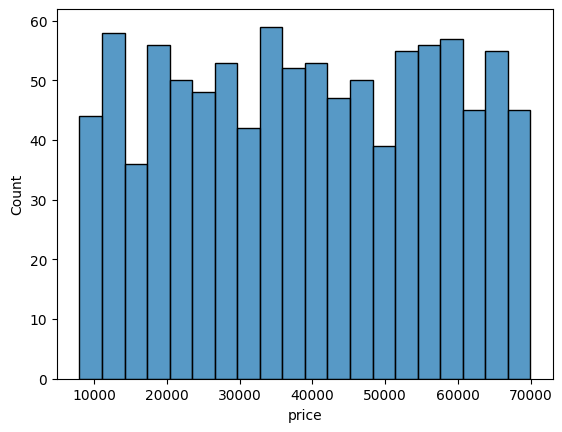

In [15]:
sns.histplot(train_df['price'],bins=20)

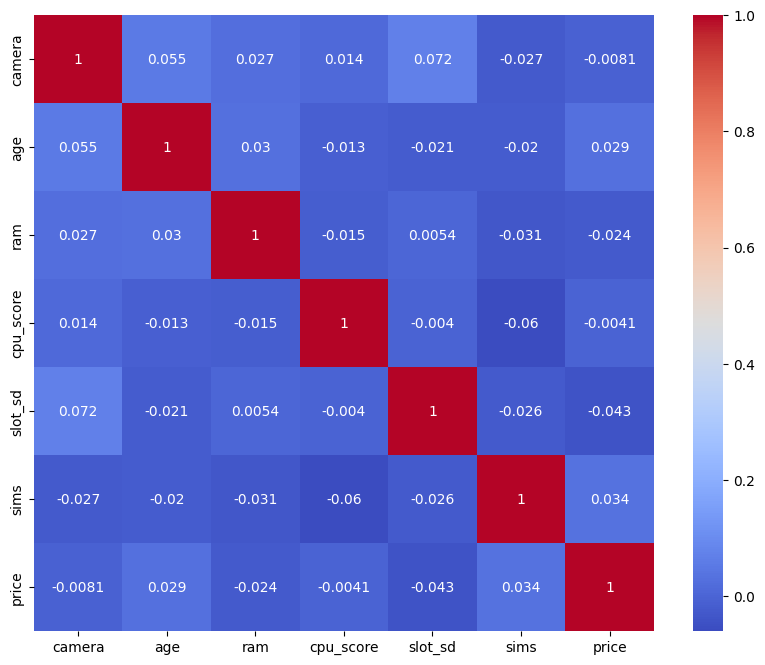

In [16]:
corr_matrix = train_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

## 3. Machine Learning

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
X_train = train_df.drop(columns=["price"])
y_train = train_df["price"]
X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]

In [19]:
# Define Random Forest Model
rf = RandomForestRegressor(n_estimators=200, random_state=42)

In [20]:
rf.fit(X_train.values, y_train.values)

RandomForestRegressor(n_estimators=200, random_state=42)

In [21]:
y_pred = rf.predict(X_test.values)

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 5656.809104166667
MSE : 44265254.254253276
RMSE: 6653.213828989211
R²  : 0.8452631415631431


In [23]:
result = pd.DataFrame({
    "prediction": y_pred,
    "actual": y_test.values
})
result.to_csv("/result.csv", index=False)
result.head()

,prediction,actual
0,21039.380,11722
1,24830.650,12906
2,40923.525,38096
3,45555.115,48031
4,28252.060,21699


In [24]:
# Accuracy for regression: fraction of predictions within a relative tolerance of the true price
tolerance = 0.10  # 10%
within_tol = (result['prediction'].sub(result['actual']).abs() <= tolerance * result['actual'])
accuracy = within_tol.mean()
error_percentage = (1 - accuracy) * 100

print(f"Accuracy (within {tolerance*100:.0f}%): {accuracy * 100:.2f}%")
print(f"Error Percentage: {error_percentage:.2f}%")
print(f"\nNumber of correct predictions: {within_tol.sum()}")
print(f"Number of incorrect predictions: {(~within_tol).sum()}")

# Also report exact-match accuracy (usually near 0 for continuous targets)
exact_match = (result['prediction'].round().astype(int) == result['actual'])
print(f"\nExact-match Accuracy: {exact_match.mean() * 100:.2f}%")
print(f"Exact correct: {exact_match.sum()}, exact incorrect: {(~exact_match).sum()}")

Accuracy (within 10%): 40.00%
Error Percentage: 60.00%

Number of correct predictions: 80
Number of incorrect predictions: 120

Exact-match Accuracy: 0.00%
Exact correct: 0, exact incorrect: 200
